# Iris Flower Prediction 


In [58]:
"""

!pip install ipykernel
!pip install scikit-learn
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

"""


'\n\n!pip install ipykernel\n!pip install scikit-learn\n!pip install pandas\n!pip install matplotlib\n!pip install seaborn\n!pip install scikit-learn\n\n'


# 1. importing all basic libaries 

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (r2_score, accuracy_score, precision_score, 
                           recall_score, f1_score)


# 2. data loading and refining


In [60]:
iris_df = pd.read_csv("dataset/iris_dataset.csv")

#iris_df = sns.load_dataset('iris')

iris_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [61]:
iris_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


# 3. Visualization

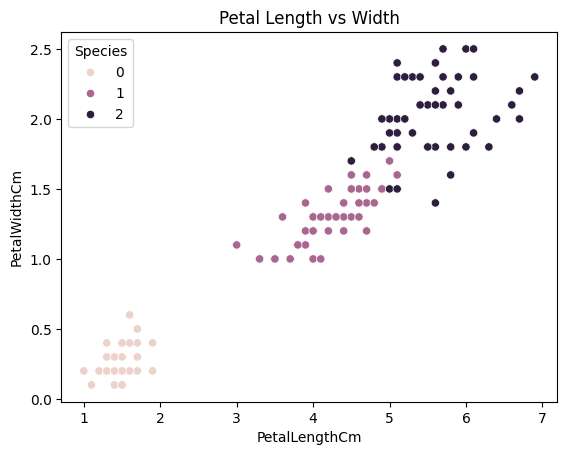

In [83]:
sns.scatterplot(data=iris_df, x='PetalLengthCm', y='PetalWidthCm', hue='Species')
plt.title('Petal Length vs Width')
plt.show()

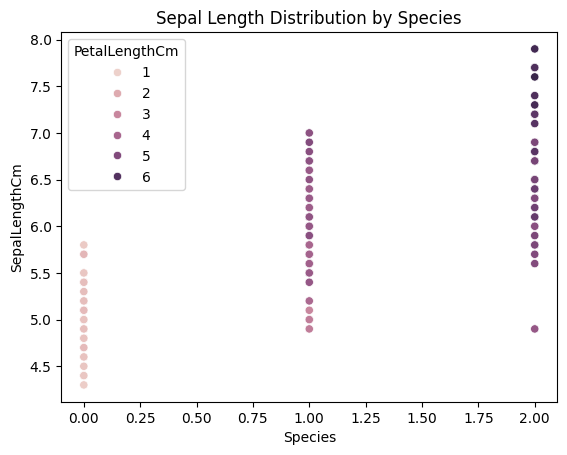

In [73]:
sns.scatterplot(data=iris_df, x='Species', y='SepalLengthCm' , hue='PetalLengthCm')
plt.title('Sepal Length Distribution by Species')
plt.show()

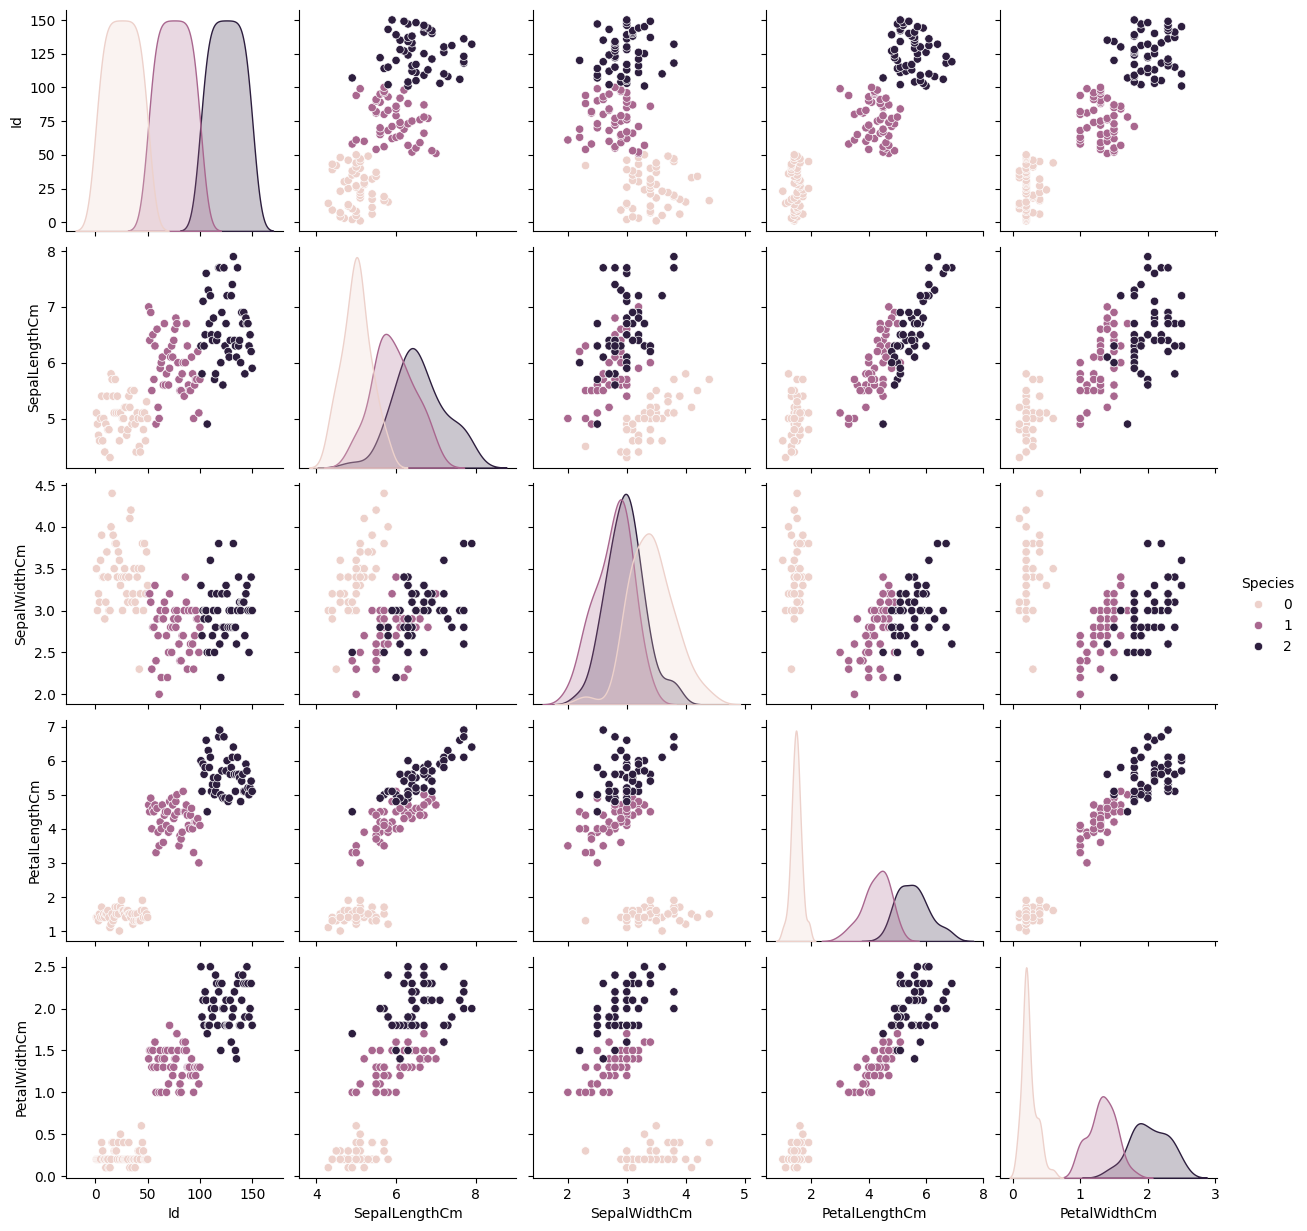

In [79]:
sns.pairplot(iris_df, hue='Species')
plt.show()

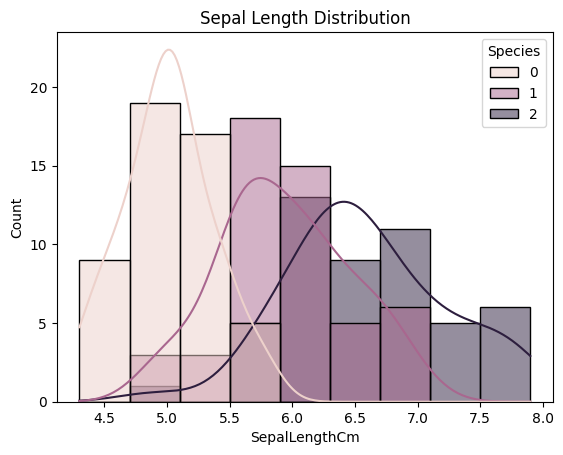

In [82]:
sns.histplot(data=iris_df, x='SepalLengthCm', hue='Species', kde=True)
plt.title('Sepal Length Distribution')
plt.show()

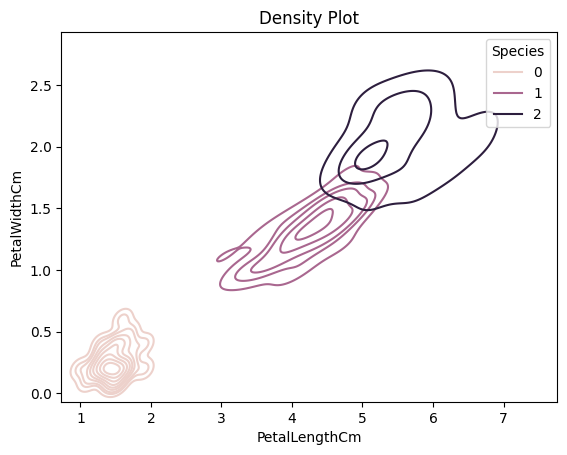

In [87]:
sns.kdeplot(data=iris_df, x='PetalLengthCm', y='PetalWidthCm', hue='Species')
plt.title('Density Plot')
plt.show()

In [63]:
#Mapping the speices
iris_df["Species"] = iris_df["Species"].map({"Iris-setosa" : 0,
                                             "Iris-versicolor" :1,
                                             "Iris-virginica": 2
                                             })


iris_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


# 4. Train Test Split

In [64]:
X = iris_df.drop(columns= ["Species" , "Id"])
Y = iris_df["Species"]

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")


Training set size: 120 samples
Testing set size: 30 samples
Number of features: 4


# 4.1 Training data on logistic reg


In [72]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=10,
    solver='lbfgs'  
).fit(X_train, Y_train)

In [67]:
Y_predict = log_model.predict(X_test)

#calculate metrics
print(f"Accuracy: {accuracy_score(Y_test, Y_predict)*100:.2f}%")
print(f"Precision: {precision_score(Y_test, Y_predict,average='micro')*100:.2f}%")
print(f"Recall: {recall_score(Y_test, Y_predict,average='micro')*100:.2f}%")
print(f"F1-Score: {f1_score(Y_test, Y_predict,average='micro')*100:.2f}%")
print(f"R2 Score: {r2_score(Y_test, Y_predict):.4f}")

Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1-Score: 100.00%
R2 Score: 1.0000


# 4.2 Training data on Navie bayes

In [68]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB().fit(X_train, Y_train)

Y_pred = gnb.predict(X_test)

#calculate metrics
print(f"Accuracy: {accuracy_score(Y_test, Y_pred)*100:.2f}%")
print(f"Precision: {precision_score(Y_test, Y_pred,average='micro')*100:.2f}%")
print(f"Recall: {recall_score(Y_test, Y_pred,average='micro')*100:.2f}%")
print(f"F1-Score: {f1_score(Y_test, Y_pred,average='micro')*100:.2f}%")
print(f"R2 Score: {r2_score(Y_test, Y_pred):.4f}")

Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1-Score: 100.00%
R2 Score: 1.0000


# 4.3. Training data on KNN

In [69]:
from sklearn.neighbors import KNeighborsClassifier

KNN = KNeighborsClassifier(n_neighbors=3).fit(X_train, Y_train)

Y_prediction = KNN.predict(X_test)

#calculate metrics
print(f"Accuracy: {accuracy_score(Y_test, Y_prediction)*100:.2f}%")
print(f"Precision: {precision_score(Y_test, Y_prediction,average='micro')*100:.2f}%")
print(f"Recall: {recall_score(Y_test, Y_prediction,average='micro')*100:.2f}%")
print(f"F1-Score: {f1_score(Y_test, Y_prediction,average='micro')*100:.2f}%")
print(f"R2 Score: {r2_score(Y_test, Y_prediction):.4f}")


Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1-Score: 100.00%
R2 Score: 1.0000


# 6. Pickling the Model For deployment
 

In [70]:
import pickle

# Save the trained model to a file
with open("models/iris_model.pkl", "wb") as file:  #
    pickle.dump(KNN, file)

# 7. Making the requirement File

In [71]:
import pkg_resources

# List of the packages you know you're using
required_packages = [
    'numpy',
    'pandas',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'ipykernel',
]

requirements = []

for package in required_packages:
    try:
        version = pkg_resources.get_distribution(package).version
        requirements.append(f"{package}=={version}")
    except pkg_resources.DistributionNotFound:
        print(f"Package {package} not found in the environment.")

#requirements to a file
with open('requirements.txt', 'w') as f:
    for line in requirements:
        f.write(line + '\n')